# Training Curves Analysis

This notebook visualizes training progress for supervised and semi-supervised (FixMatch) experiments.
It loads training logs (CSV) from experiment output directories and plots:
- Loss curves (train/val)
- Accuracy and AUC-ROC over epochs
- Comparison between supervised and SSL under different labeled subset sizes


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import glob
import os
from pathlib import Path

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'configs').exists() and (candidate / 'src').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate project root from the current notebook kernel.')

PROJECT_ROOT = find_project_root()

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12, 6)


## Locate Experiment Outputs

By default, experiments are saved in `results/` (or custom output directory). The following cell searches for training log CSV files.

In [2]:
candidate_dirs = [PROJECT_ROOT / 'results_rescue', PROJECT_ROOT / 'results_v2', PROJECT_ROOT / 'results']
existing_dirs = [p for p in candidate_dirs if p.exists()]

if not existing_dirs:
    print('No results directory found. Please run experiments first.')
    print('You can run a quick test with:')
    print('  python scripts/train_supervised.py --config configs/test.yaml --labeled_subset 10 --output_dir test_output')
else:
    base_dir = existing_dirs[0]
    csv_files = list(base_dir.glob('**/training_history.csv'))
    print(f'Using results directory: {base_dir}')
    print(f'Found {len(csv_files)} training history files:')
    for f in csv_files:
        print(f'  - {f.relative_to(base_dir)}')


Using results directory: /Users/grmim/Dev/ssl/results_v2
Found 7 training history files:
  - supervised_100/training_history.csv
  - supervised_500/training_history.csv
  - fixmatch_500/training_history.csv
  - fixmatch_100/training_history.csv
  - fixmatch_250/training_history.csv
  - supervised_250/training_history.csv
  - supervised_full/training_history.csv


## Load and Prepare Data

Load all training history CSV files into a single DataFrame with metadata.

In [3]:
def load_experiment_logs(csv_files):
    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        df['epoch'] = np.arange(1, len(df) + 1)
        rel_path = f.relative_to(base_dir)
        parts = rel_path.parts
        df['experiment'] = parts[0]
        exp_name = parts[0].lower()
        if 'mean_teacher' in exp_name:
            df['method'] = 'mean_teacher'
        elif 'fixmatch' in exp_name:
            df['method'] = 'fixmatch'
        elif 'supervised' in exp_name:
            df['method'] = 'supervised'
        else:
            df['method'] = 'unknown'
        import re
        match = re.search(r'(\d+)', exp_name)
        df['labeled_samples'] = int(match.group(1)) if match else np.nan
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

if 'csv_files' in locals() and csv_files:
    df_all = load_experiment_logs(csv_files)
    print(f'Loaded {len(df_all)} rows from {len(csv_files)} experiments.')
    print('Columns:', df_all.columns.tolist())
    print('\nUnique experiments:')
    print(df_all[['experiment', 'method', 'labeled_samples']].drop_duplicates().sort_values(['method', 'labeled_samples']))


Loaded 466 rows from 7 experiments.
Columns: ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'train_auc', 'val_auc', 'learning_rate', 'epoch', 'experiment', 'method', 'labeled_samples', 'sup_loss', 'unsup_loss', 'mask_ratio', 'lambda_u']

Unique experiments:
          experiment      method  labeled_samples
235     fixmatch_100    fixmatch            100.0
274     fixmatch_250    fixmatch            250.0
109     fixmatch_500    fixmatch            500.0
0     supervised_100  supervised            100.0
308   supervised_250  supervised            250.0
41    supervised_500  supervised            500.0
377  supervised_full  supervised              NaN


## Loss Curves

Plot training and validation loss over epochs for each experiment.

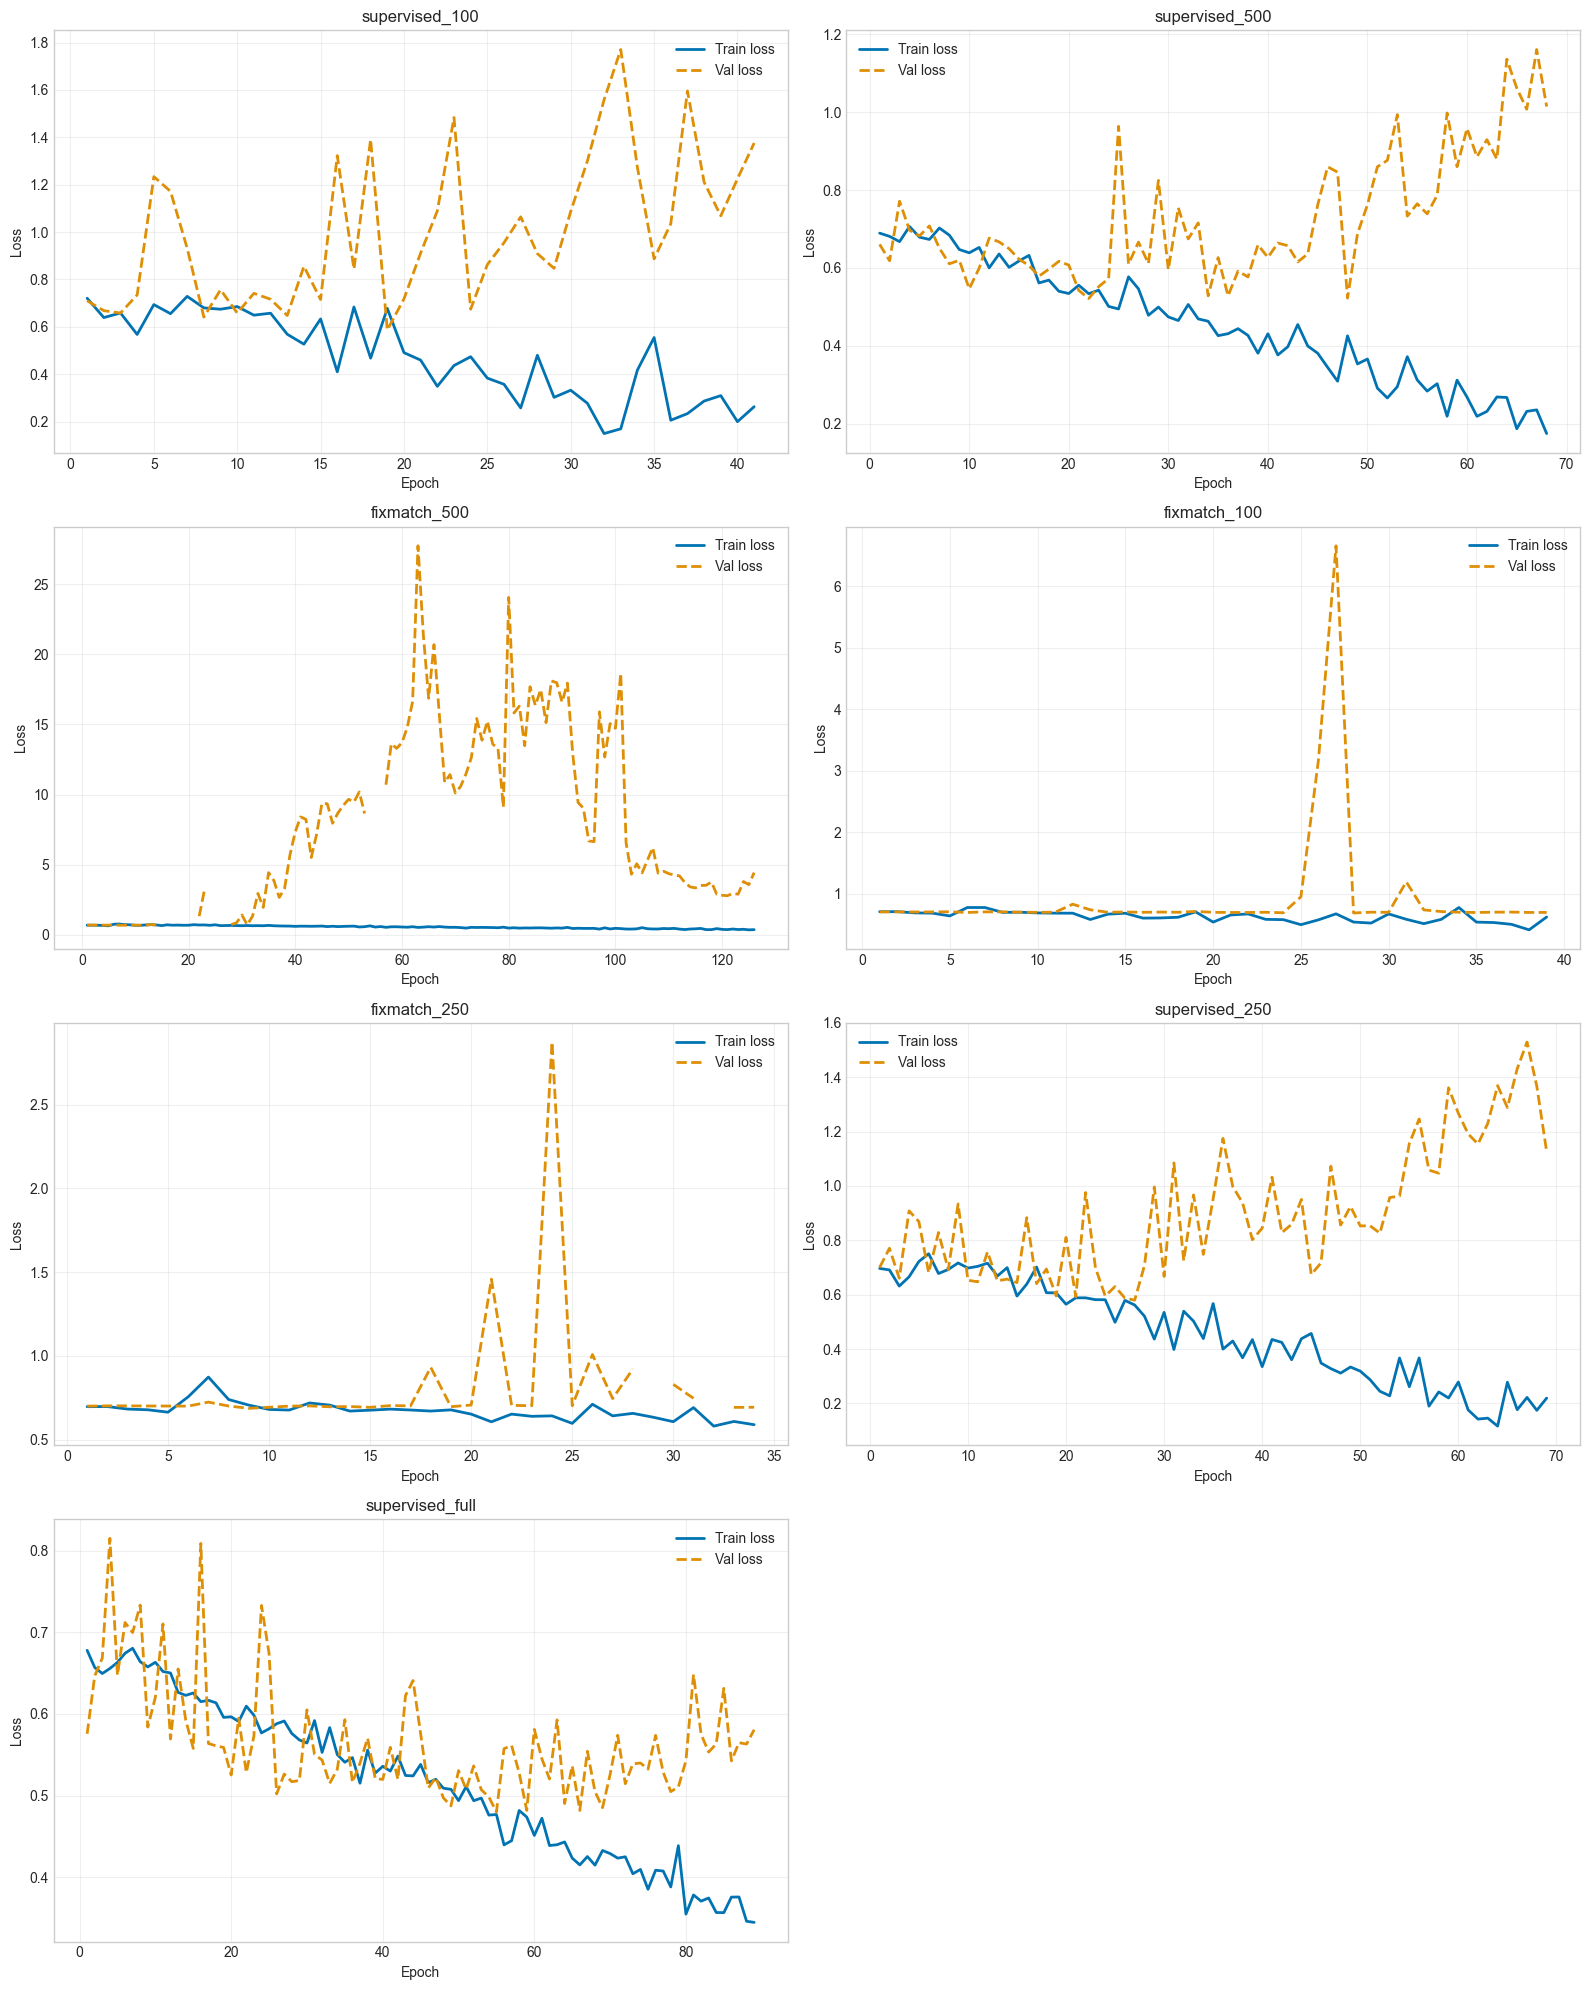

In [4]:
if 'df_all' in locals() and not df_all.empty:
    experiments = list(df_all['experiment'].unique())
    n_cols = 2
    n_rows = int(np.ceil(len(experiments) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, exp in enumerate(experiments):
        group = df_all[df_all['experiment'] == exp].sort_values('epoch')
        ax = axes[idx]
        ax.plot(group['epoch'], group['train_loss'], label='Train loss', linewidth=2)
        if 'val_loss' in group.columns:
            ax.plot(group['epoch'], group['val_loss'], label='Val loss', linewidth=2, linestyle='--')
        ax.set_title(exp)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

    for ax in axes[len(experiments):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Accuracy and AUC Comparison

Compare final validation accuracy and AUC across methods and labeled subset sizes.

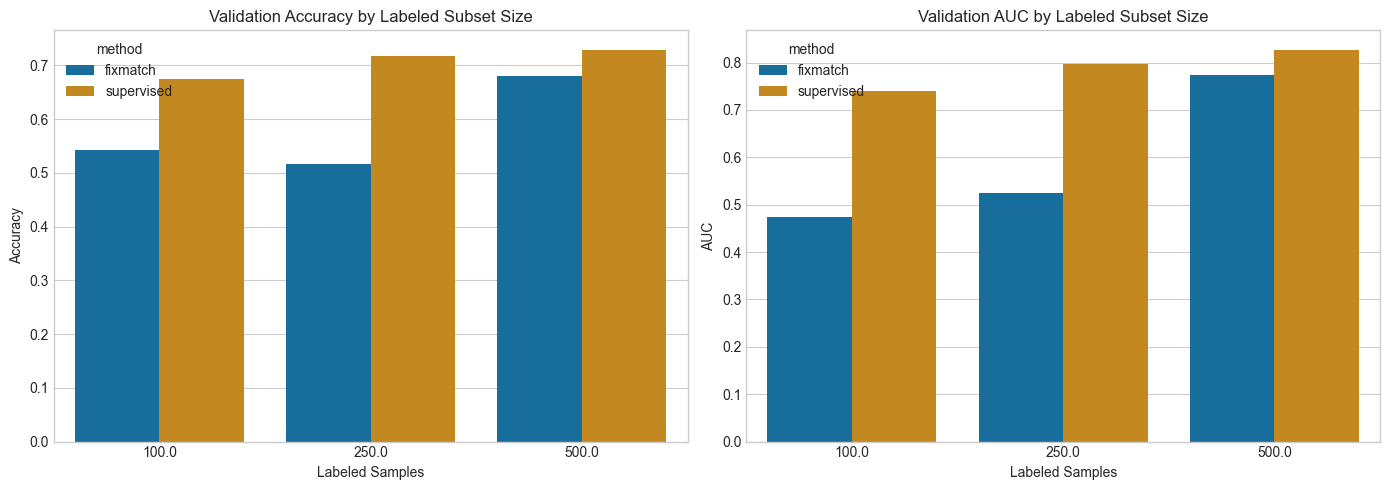

In [5]:
if 'df_all' in locals() and not df_all.empty:
    last_epochs = df_all.sort_values('epoch').groupby('experiment', as_index=False).tail(1)
    last_epochs = last_epochs[last_epochs['labeled_samples'].notna()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=last_epochs, x='labeled_samples', y='val_acc', hue='method', ax=ax1)
    ax1.set_title('Validation Accuracy by Labeled Subset Size')
    ax1.set_xlabel('Labeled Samples')
    ax1.set_ylabel('Accuracy')

    if 'val_auc' in last_epochs.columns:
        sns.barplot(data=last_epochs, x='labeled_samples', y='val_auc', hue='method', ax=ax2)
        ax2.set_title('Validation AUC by Labeled Subset Size')
        ax2.set_xlabel('Labeled Samples')
        ax2.set_ylabel('AUC')
    else:
        ax2.text(0.5, 0.5, 'AUC column not found', ha='center', va='center')
        ax2.set_title('Validation AUC (not available)')

    plt.tight_layout()
    plt.show()


## SSL‑Specific Metrics (FixMatch)

For FixMatch experiments, plot pseudo‑label accuracy and consistency loss over epochs.

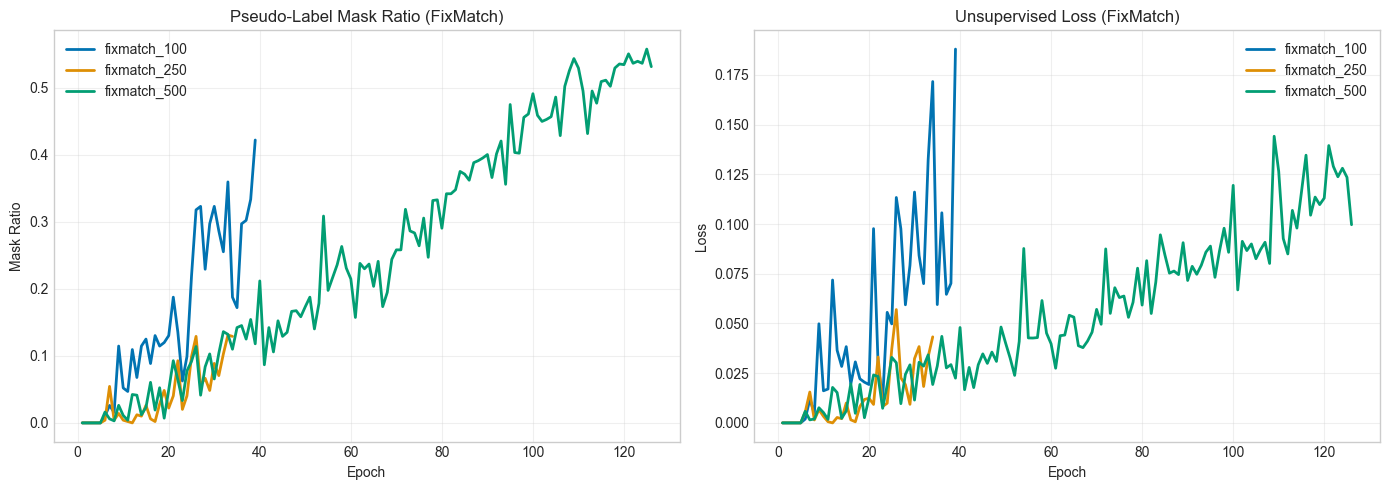

In [6]:
if 'df_all' in locals() and not df_all.empty:
    ssl_df = df_all[df_all['method'] == 'fixmatch']
    if not ssl_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for exp, group in ssl_df.groupby('experiment'):
            group = group.sort_values('epoch')
            if 'mask_ratio' in group.columns:
                axes[0].plot(group['epoch'], group['mask_ratio'], label=exp, linewidth=2)
            if 'unsup_loss' in group.columns:
                axes[1].plot(group['epoch'], group['unsup_loss'], label=exp, linewidth=2)

        axes[0].set_title('Pseudo-Label Mask Ratio (FixMatch)')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Mask Ratio')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].set_title('Unsupervised Loss (FixMatch)')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print('No FixMatch experiments found in the selected results directory.')


## Summary

This notebook provides a template for analyzing training logs. To generate actual data, run the ablation study with `./run_ablation.sh`.